In [18]:
import pandas as pd

In [19]:
#1a. Load fx file
fx = pd.read_csv("/Users/chewy/Downloads/ST2195/ST2195 Data Files/Block 6/fx.csv", usecols=[0,2])
fx.columns = ['date', 'exchange_rate']  #set column names
fx['date'] = pd.to_datetime(fx['date'])

In [20]:
#1b. Load speeches file
speeches = pd.read_csv("/Users/chewy/Downloads/ST2195/ST2195 Data Files/Block 6/speeches.csv", sep='|')
speeches = speeches[['date', 'contents']] #select column names
speeches['date'] = pd.to_datetime(speeches['date'])

In [21]:
#1c. Remove missing values
speeches.dropna(inplace=True, subset=['contents']) #subset specifies which column to check for missing values

In [22]:
#1d. Group 'contents' by 'date', then join all contents by date
speeches = speeches.groupby('date')['contents'].apply(lambda x: " ".join(x)).reset_index()

In [23]:
#1e. Merge fx and speeches data into one dataset
df = pd.merge(fx, speeches, on='date', how='left')
df.set_index('date', inplace= True)

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 7068 entries, 1999-01-04 to 2026-05-15
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   exchange_rate  7006 non-null   float64
 1   contents       2043 non-null   object 
dtypes: float64(1), object(1)
memory usage: 165.7+ KB


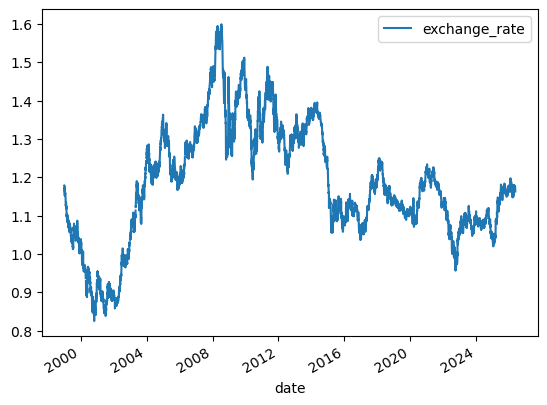

In [24]:
#2. Remove entries with obvious outliers or mistakes
df.plot()
df.describe()
df.info()

The data does not seem to have obvious outliers or mistakes. 

In [25]:
#3. Fill missing observations for the exchange rates
df.exchange_rate = df.exchange_rate.ffill()

In [26]:
#4. Calculate exchange rate return
# 'df.exchange_rate.pct_change(1)' computes % change from previous exchange rate
df['return'] = df.exchange_rate.pct_change(1)

In [27]:
#5a. Allocate variables "good_news" and "bad_news"
df['good_news'] = (df['return'] > 0.5/100).astype(int)
df['bad_news'] = (df['return'] < -0.5/100).astype(int)

In [28]:
#5b. Remove rows with NA
df.dropna(inplace=True)

In [29]:
#5c. Get the contents related to "good_news" and "bad_news"
# pandas.Series.str.cat concatenates strings with given separator
good_news_contents = df.contents[df.good_news==1].str.cat(sep=' ')
bad_news_contents = df.contents[df.bad_news==1].str.cat(sep=' ')

In [30]:
#5d. Create function to find frequent stop words
stop_words = set(pd.read_csv("/Users/chewy/Downloads/ST2195/ST2195 Data Files/Block 6/stop_words_english.txt", header=None).iloc[:,0].tolist())

import string

def get_word_freq(contents, stop_words, num_words):
    
    freq = dict()
    
    for word in contents.split():
        
        word = word.strip(string.punctuation+'–')  #remove all punctuations
        word = word.lower()  #convert to lower case
        
        if (word not in stop_words) and len(word):
            if word in freq:
                freq[word] += 1
            else:
                freq[word] = 1

    freq = dict(sorted(freq.items(), 
                       key = lambda item: item[1], 
                       reverse = True)) 
    return list(freq.items())[:num_words]

In [31]:
#5c. Use function for 20 most common words
good_indicators = get_word_freq(good_news_contents, stop_words, num_words = 20)
bad_indicators = get_word_freq(bad_news_contents, stop_words, num_words = 20)
good_indicators
bad_indicators

[('euro', 8164),
 ('financial', 7295),
 ('policy', 6562),
 ('monetary', 6214),
 ('area', 5688),
 ('central', 4197),
 ('market', 4148),
 ('economic', 3905),
 ('banks', 3863),
 ('stability', 3423),
 ('european', 3370),
 ('inflation', 3288),
 ('ecb', 3272),
 ('bank', 3079),
 ('growth', 2935),
 ('price', 2885),
 ('markets', 2734),
 ('la', 2587),
 ('countries', 2551),
 ('risk', 2348)]